# 📊 Notebook 01 — Exploratory Data Analysis (EDA)
## Human Intrusion Detection System

**GPU**: NVIDIA Quadro T2000 (4GB VRAM)  
**Task**: Person-only intrusion detection  
**Datasets**: COCO 2017 + MOT17 + VIRAT Ground  

### Objectives
1. Verify GPU availability and CUDA setup
2. Explore COCO 2017 person annotations
3. Analyze class distribution, image sizes, bbox statistics
4. Visualize sample frames from each dataset
5. Understand data quality and preprocessing needs

---

## 🔧 Section 1 — Environment Setup & GPU Check

In [1]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Install dependencies ignoring strict torch pins
%pip install opencv-python ultralytics lap scipy filterpy Shapely albumentations loguru fastapi uvicorn[standard]


  Using cached lap-0.5.13-cp313-cp313-win_amd64.whl.metadata (6.8 kB)
  Using cached filterpy-1.4.5.zip (177 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached fastapi-0.136.3-py3-none-any.whl.metadata (27 kB)
  Using cached uvicorn-0.49.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached starlette-1.2.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached httptools-0.8.0-cp313-cp313-win_amd64.whl.metadata (3.7 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached watchfile


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Install required libraries (run once)
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

packages = [
    'torch torchvision --index-url https://download.pytorch.org/whl/cu118',
    'ultralytics',
    'opencv-python',
    'matplotlib',
    'seaborn',
    'pandas',
    'pycocotools',
    'albumentations',
    'shapely',
    'tqdm',
    'loguru',
    'pyyaml',
]

print('Installing packages...')
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkg.split())
print('✅ All packages installed.')

Installing packages...


✅ All packages installed.


In [19]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd
import json
import os
import sys
from pathlib import Path
from collections import Counter, defaultdict

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='darkgrid', palette='viridis')

# ── GPU Check ────────────────────────────────────────────────
print('=' * 55)
print('  🖥️  Environment Check')
print('=' * 55)
print(f'Python     : {sys.version.split()[0]}')
print(f'PyTorch    : {torch.__version__}')
print(f'OpenCV     : {cv2.__version__}')
print(f'CUDA Avail : {torch.cuda.is_available()}')

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    vram_gb = gpu.total_memory / 1e9
    print(f'GPU Name   : {gpu.name}')
    print(f'VRAM       : {vram_gb:.2f} GB')
    print(f'CUDA Cap   : {gpu.major}.{gpu.minor}')
    print(f'SM Count   : {gpu.multi_processor_count}')
    
    if 'T2000' in gpu.name or vram_gb < 5:
        print()
        print('⚠️  Quadro T2000 / < 5GB VRAM detected.')
        print('   → Using YOLOv8s + batch_size=8 + FP16 (optimal)')
    
    # Quick tensor test
    x = torch.rand(3, 640, 640).cuda()
    print(f'\n✅ CUDA tensor test passed: {x.shape} on {x.device}')
else:
    print('❌ CUDA not available — running on CPU (much slower!)')

print('=' * 55)

  🖥️  Environment Check
Python     : 3.13.2
PyTorch    : 2.7.1+cu118
OpenCV     : 4.13.0
CUDA Avail : True
GPU Name   : Quadro T2000
VRAM       : 4.29 GB
CUDA Cap   : 7.5
SM Count   : 16

⚠️  Quadro T2000 / < 5GB VRAM detected.
   → Using YOLOv8s + batch_size=8 + FP16 (optimal)

✅ CUDA tensor test passed: torch.Size([3, 640, 640]) on cuda:0


In [5]:
# ── Project paths ────────────────────────────────────────────
import sys
from pathlib import Path
# ── Project paths ────────────────────────────────────────────
# Adjust ROOT to your actual project path
# Fix: Robust root detection (works from any Jupyter launch directory)
def _find_root():
    for p in [Path.cwd()] + list(Path.cwd().parents):
        if (p / 'src').is_dir() and (p / 'requirements.txt').exists():
            return p
    return Path.cwd()
ROOT = _find_root()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
print(f'Project root: {ROOT}')
print(f'src/ found  : {(ROOT / "src").is_dir()}')
DATA_DIR   = ROOT / 'data' / 'raw'
COCO_DIR   = DATA_DIR / 'coco'
MOT17_DIR  = DATA_DIR / 'mot17'
VIRAT_DIR  = DATA_DIR / 'virat'
ZONES_FILE = ROOT / 'data' / 'zones' / 'zones_config.json'

print(f'Project root : {ROOT}')
print(f'COCO dir     : {COCO_DIR}')
print(f'MOT17 dir    : {MOT17_DIR}')
print(f'Zones config : {ZONES_FILE}')

# Create dirs if not exist
for d in [DATA_DIR, COCO_DIR, MOT17_DIR, VIRAT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print('\n✅ Directories ready.')

Project root: c:\Users\kesha\.gemini\antigravity-ide\scratch\intrusion-detection
src/ found  : True
Project root : c:\Users\kesha\.gemini\antigravity-ide\scratch\intrusion-detection
COCO dir     : c:\Users\kesha\.gemini\antigravity-ide\scratch\intrusion-detection\data\raw\coco
MOT17 dir    : c:\Users\kesha\.gemini\antigravity-ide\scratch\intrusion-detection\data\raw\mot17
Zones config : c:\Users\kesha\.gemini\antigravity-ide\scratch\intrusion-detection\data\zones\zones_config.json

✅ Directories ready.


In [6]:
%pip install ipywidgets


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📥 Section 2 — Dataset Download (COCO 2017 Person Subset)

In [7]:
import urllib.request
import zipfile
from tqdm.notebook import tqdm

COCO_URLS = {
    'val_images'  : 'http://images.cocodataset.org/zips/val2017.zip',
    'annotations' : 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip',
    # Uncomment for full training set (~18GB):
    # 'train_images': 'http://images.cocodataset.org/zips/train2017.zip',
}

def download_with_progress(url, dest):
    dest = Path(dest)
    if dest.exists():
        print(f'  Already downloaded: {dest.name}')
        return
    print(f'  Downloading: {url.split("/")[-1]} ...')
    
    class _Bar(tqdm):
        def update_to(self, b=1, bsize=1, tsize=None):
            if tsize: self.total = tsize
            self.update(b * bsize - self.n)
    
    with _Bar(unit='B', unit_scale=True, miniters=1, desc=dest.name) as t:
        urllib.request.urlretrieve(url, dest, reporthook=t.update_to)
    print(f'  ✅ Saved: {dest}')

def extract_zip(zip_path, out_dir):
    zip_path, out_dir = Path(zip_path), Path(out_dir)
    print(f'  Extracting: {zip_path.name} ...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(out_dir)
    print(f'  ✅ Extracted to: {out_dir}')

print('Downloading COCO 2017 (val + annotations)...')
print('NOTE: Train set (~18GB) is commented out — download separately.')
print()

for name, url in COCO_URLS.items():
    fname = url.split('/')[-1]
    zip_path = COCO_DIR / fname
    download_with_progress(url, zip_path)
    if zip_path.exists() and not (COCO_DIR / fname.replace('.zip', '')).exists():
        extract_zip(zip_path, COCO_DIR)

print('\n✅ COCO 2017 download complete!')

NOTE: Train set (~18GB) is commented out — download separately.

  Already downloaded: val2017.zip
  Already downloaded: annotations_trainval2017.zip
  Extracting: annotations_trainval2017.zip ...
  ✅ Extracted to: c:\Users\kesha\.gemini\antigravity-ide\scratch\intrusion-detection\data\raw\coco

✅ COCO 2017 download complete!


## 🔍 Section 3 — COCO Person Annotation EDA

In [8]:
import json
from collections import Counter, defaultdict
import numpy as np
# Load COCO val annotations
ann_file = COCO_DIR / 'annotations' / 'instances_val2017.json'

if not ann_file.exists():
    print(f'❌ Annotation file not found: {ann_file}')
    print('   Download COCO annotations first (cell above).')
else:
    print(f'Loading: {ann_file} ...')
    with open(ann_file) as f:
        coco_data = json.load(f)
    
    print(f'\n📊 COCO Val 2017 Stats:')
    print(f'  Total images      : {len(coco_data["images"]):,}')
    print(f'  Total annotations : {len(coco_data["annotations"]):,}')
    print(f'  Categories        : {len(coco_data["categories"])}')
    
    # Filter person annotations (category_id = 1 in COCO)
    PERSON_CAT_ID = 1
    person_anns = [a for a in coco_data['annotations'] 
                   if a['category_id'] == PERSON_CAT_ID and a['area'] > 0]
    
    # Images with at least one person
    person_img_ids = set(a['image_id'] for a in person_anns)
    
    print(f'\n🧍 Person-Specific Stats:')
    print(f'  Images with persons      : {len(person_img_ids):,}')
    print(f'  Person annotations total : {len(person_anns):,}')
    print(f'  Avg persons per image    : {len(person_anns)/len(person_img_ids):.2f}')
    
    # Persons per image distribution
    persons_per_img = Counter(a['image_id'] for a in person_anns)
    counts = list(persons_per_img.values())
    print(f'  Max persons in one image : {max(counts)}')
    print(f'  Median persons per image : {np.median(counts):.1f}')

Loading: c:\Users\kesha\.gemini\antigravity-ide\scratch\intrusion-detection\data\raw\coco\annotations\instances_val2017.json ...

📊 COCO Val 2017 Stats:
  Total images      : 5,000
  Total annotations : 36,781
  Categories        : 80

🧍 Person-Specific Stats:
  Images with persons      : 2,693
  Person annotations total : 11,004
  Avg persons per image    : 4.09
  Max persons in one image : 14
  Median persons per image : 2.0


📐 Bounding Box Statistics:
  Avg width  (px): 88.6  |  std: 109.4
  Avg height (px): 134.4  |  std: 130.3
  Avg norm width : 0.158
  Avg norm height: 0.284
  Tiny persons (<32x32): 2,244


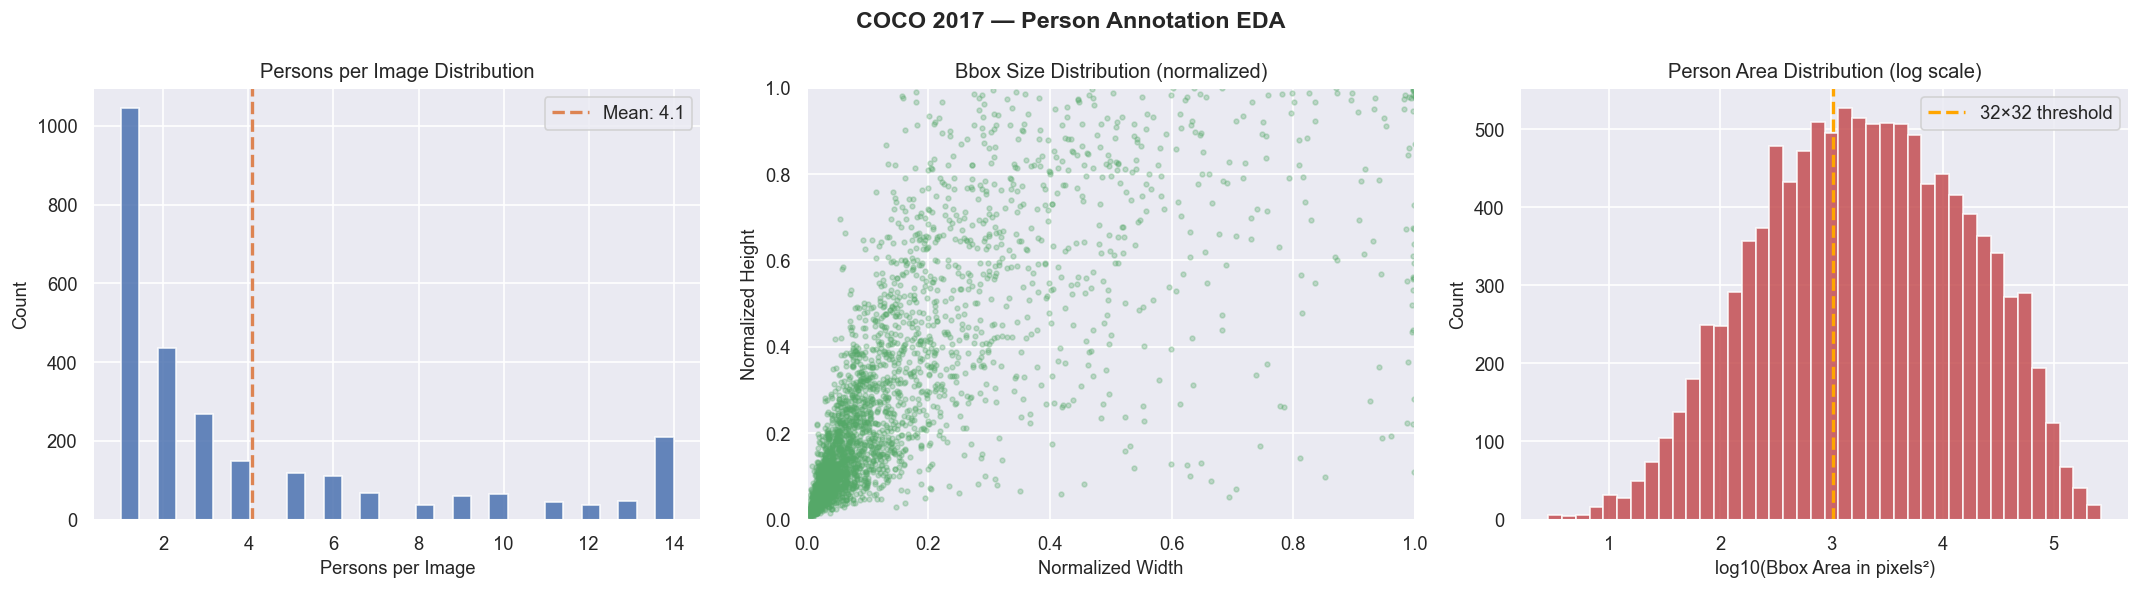


✅ EDA plot saved: eda_coco_person_stats.png


In [9]:
# ── Bounding Box Size Analysis ───────────────────────────────
if 'person_anns' in dir():
    widths  = [a['bbox'][2] for a in person_anns]  # bbox = [x, y, w, h]
    heights = [a['bbox'][3] for a in person_anns]
    areas   = [a['area'] for a in person_anns]
    
    # Normalize by image size
    img_size_map = {img['id']: (img['width'], img['height']) 
                    for img in coco_data['images']}
    norm_widths, norm_heights = [], []
    for a in person_anns:
        iw, ih = img_size_map.get(a['image_id'], (640, 480))
        norm_widths.append(a['bbox'][2] / iw)
        norm_heights.append(a['bbox'][3] / ih)
    
    print('📐 Bounding Box Statistics:')
    print(f'  Avg width  (px): {np.mean(widths):.1f}  |  std: {np.std(widths):.1f}')
    print(f'  Avg height (px): {np.mean(heights):.1f}  |  std: {np.std(heights):.1f}')
    print(f'  Avg norm width : {np.mean(norm_widths):.3f}')
    print(f'  Avg norm height: {np.mean(norm_heights):.3f}')
    print(f'  Tiny persons (<32x32): {sum(1 for w,h in zip(widths,heights) if w<32 and h<32):,}')
    
    # ── Plot: persons per image + bbox aspect ratio ───────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('COCO 2017 — Person Annotation EDA', fontsize=14, fontweight='bold')
    
    # 1. Persons per image histogram
    ax = axes[0]
    ax.hist(counts, bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(counts), color='#DD8452', lw=2, ls='--', 
               label=f'Mean: {np.mean(counts):.1f}')
    ax.set_xlabel('Persons per Image', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Persons per Image Distribution')
    ax.legend()
    
    # 2. Bbox aspect ratio scatter
    ax = axes[1]
    sample_idx = np.random.choice(len(norm_widths), min(3000, len(norm_widths)), replace=False)
    ax.scatter([norm_widths[i] for i in sample_idx],
               [norm_heights[i] for i in sample_idx],
               alpha=0.3, s=8, color='#55A868')
    ax.set_xlabel('Normalized Width', fontsize=11)
    ax.set_ylabel('Normalized Height', fontsize=11)
    ax.set_title('Bbox Size Distribution (normalized)')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    
    # 3. Bbox area distribution (log scale)
    ax = axes[2]
    ax.hist(np.log10(areas), bins=40, color='#C44E52', edgecolor='white', alpha=0.85)
    ax.set_xlabel('log10(Bbox Area in pixels²)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Person Area Distribution (log scale)')
    ax.axvline(np.log10(32*32), color='orange', ls='--', lw=2, label='32×32 threshold')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('eda_coco_person_stats.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n✅ EDA plot saved: eda_coco_person_stats.png')

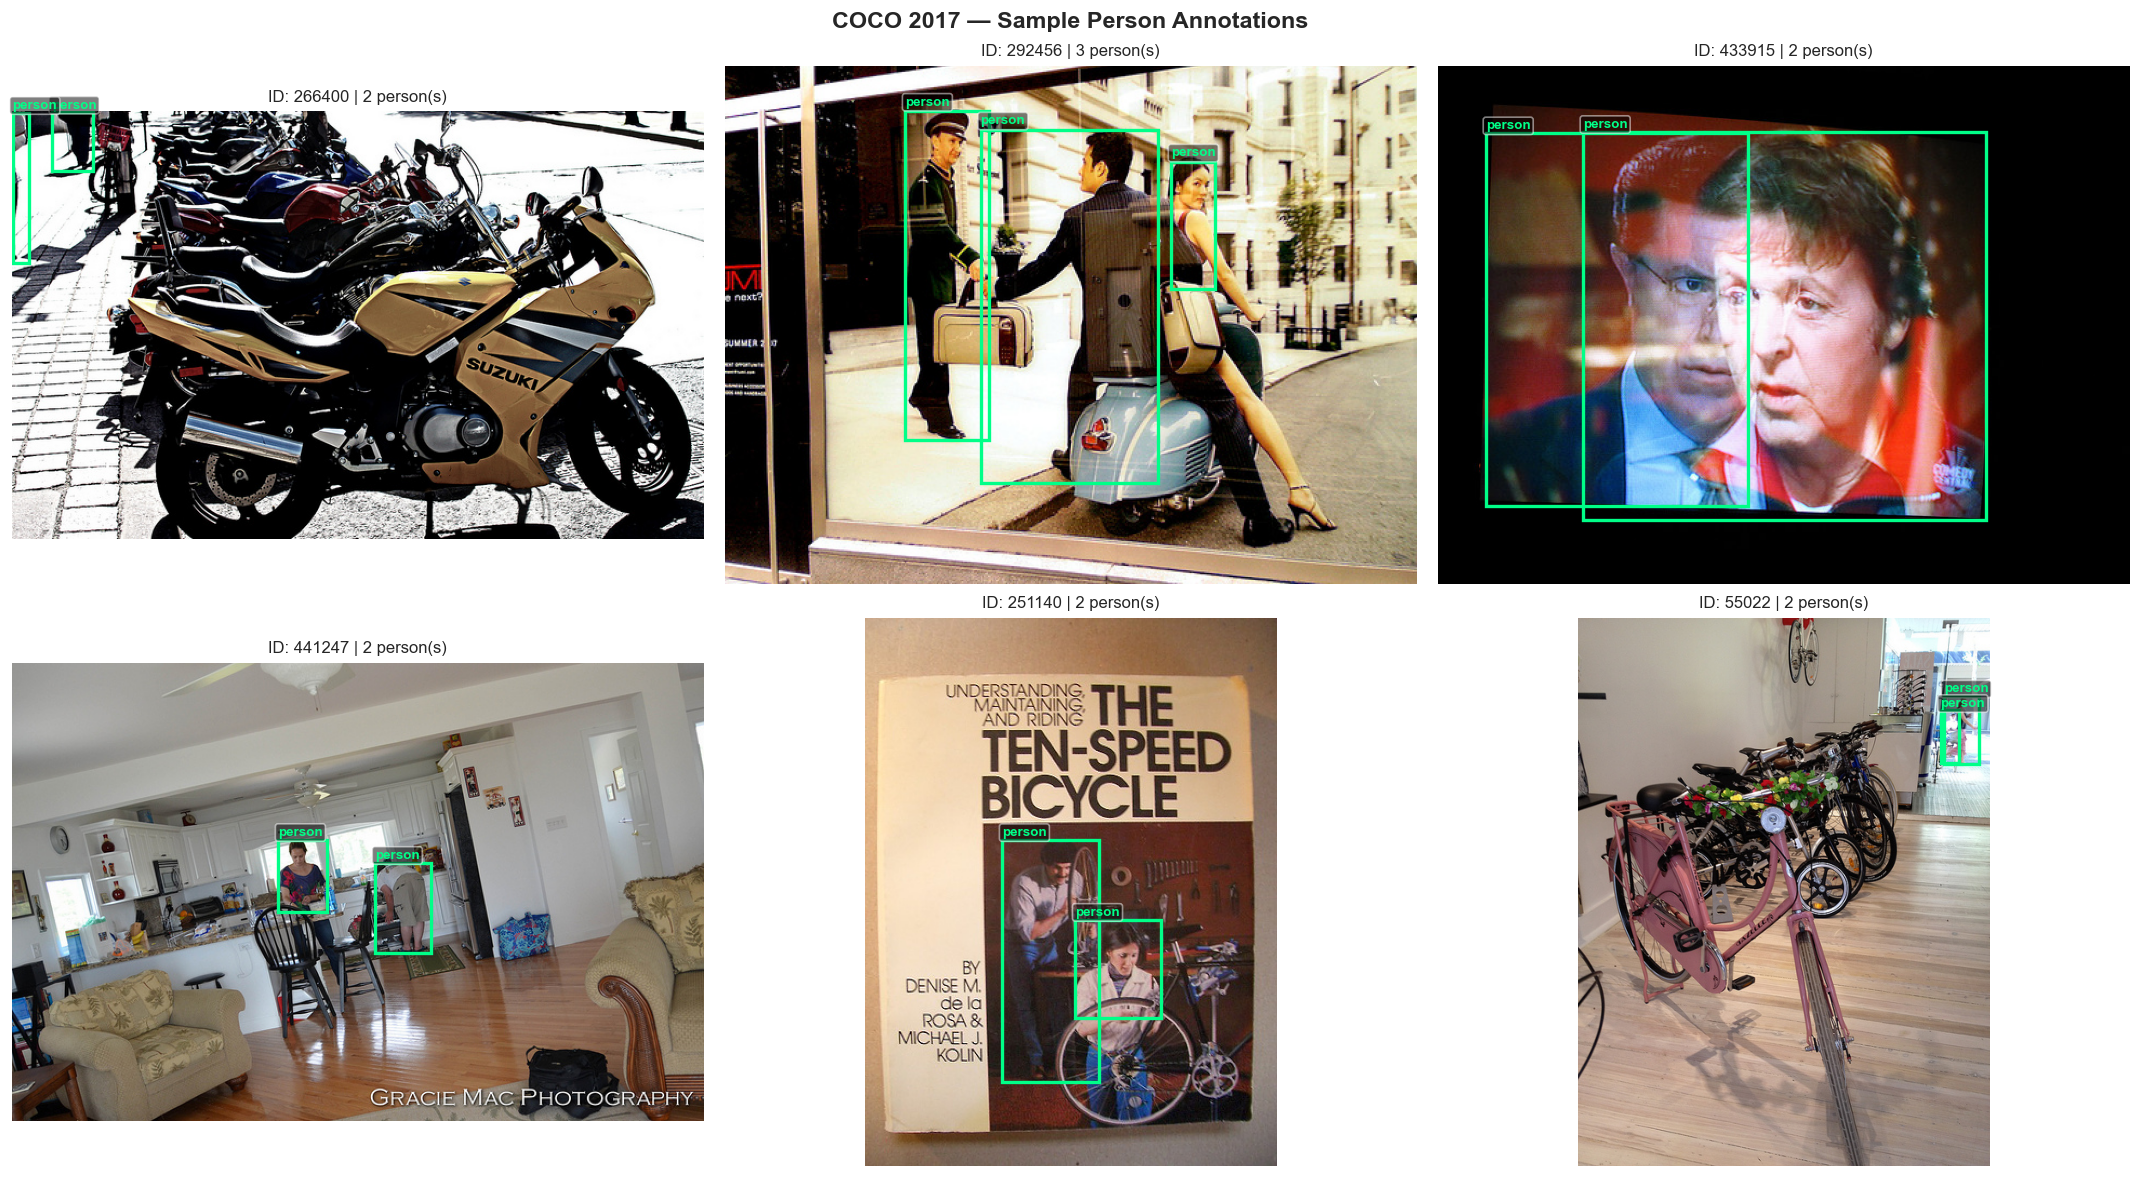

✅ Sample images visualized.


In [10]:
# ── Visualize Sample COCO Person Images ─────────────────────
img_dir = COCO_DIR / 'val2017'

if img_dir.exists() and 'person_anns' in dir():
    # Pick 6 images with 2-5 persons
    target_imgs = [img_id for img_id, cnt in persons_per_img.items() 
                   if 2 <= cnt <= 5][:6]
    
    img_id_to_info = {img['id']: img for img in coco_data['images']}
    anns_by_img = defaultdict(list)
    for a in person_anns:
        anns_by_img[a['image_id']].append(a)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('COCO 2017 — Sample Person Annotations', fontsize=14, fontweight='bold')
    
    for ax, img_id in zip(axes.flat, target_imgs):
        info = img_id_to_info[img_id]
        img_path = img_dir / info['file_name']
        
        if not img_path.exists():
            ax.text(0.5, 0.5, 'Image not\ndownloaded', ha='center', va='center')
            ax.axis('off')
            continue
        
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        
        for ann in anns_by_img[img_id]:
            x, y, w, h = ann['bbox']
            rect = patches.Rectangle((x, y), w, h,
                linewidth=2, edgecolor='#00FF88', facecolor='none')
            ax.add_patch(rect)
            ax.text(x, y-4, 'person', fontsize=8, color='#00FF88',
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))
        
        n_persons = len(anns_by_img[img_id])
        ax.set_title(f'ID: {img_id} | {n_persons} person(s)', fontsize=10)
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('eda_sample_images.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('✅ Sample images visualized.')
else:
    print('⚠️  Image directory not found. Download COCO val images first.')

In [11]:
# ── MOT17 Dataset Info ───────────────────────────────────────
print('=' * 60)
print('  📹 MOT17 Dataset Information')
print('=' * 60)
print()
print('  Download URL: https://motchallenge.net/data/MOT17.zip')
print()
print('  Structure after extraction:')
print('    MOT17/')
print('    ├── train/')
print('    │   ├── MOT17-02-DPM/  (static camera, 600 frames)')
print('    │   ├── MOT17-04-DPM/  (static camera, 1050 frames)')
print('    │   ├── MOT17-05-DPM/  (moving camera, 837 frames)')
print('    │   └── ... (14 sequences total)')
print('    └── test/')
print()
print('  Sequence Stats (training set):')
mot17_stats = [
    ('MOT17-02', 600,  'Static',  'Shopping mall'),
    ('MOT17-04', 1050, 'Static',  'Busy street'),
    ('MOT17-05', 837,  'Moving',  'Crowded market'),
    ('MOT17-09', 525,  'Static',  'Campus walkway'),
    ('MOT17-10', 654,  'Moving',  'Parking lot'),
    ('MOT17-11', 900,  'Static',  'Indoor corridor'),
    ('MOT17-13', 750,  'Moving',  'Pedestrian street'),
]
df = pd.DataFrame(mot17_stats, columns=['Sequence', 'Frames', 'Camera', 'Scene'])
print(df.to_string(index=False))
print(f'\n  Total frames: {df["Frames"].sum():,}')
print()
print('  Why MOT17 for intrusion detection?')
print('  → Dense person annotations for tracking training')
print('  → Multiple camera scenarios (static + moving)')
print('  → High-quality CCTV-style footage')
print('  → Fine-grained track IDs per person → boundary crossing training')

  📹 MOT17 Dataset Information

  Download URL: https://motchallenge.net/data/MOT17.zip

  Structure after extraction:
    MOT17/
    ├── train/
    │   ├── MOT17-02-DPM/  (static camera, 600 frames)
    │   ├── MOT17-04-DPM/  (static camera, 1050 frames)
    │   ├── MOT17-05-DPM/  (moving camera, 837 frames)
    │   └── ... (14 sequences total)
    └── test/

  Sequence Stats (training set):


Sequence  Frames Camera             Scene
MOT17-02     600 Static     Shopping mall
MOT17-04    1050 Static       Busy street
MOT17-05     837 Moving    Crowded market
MOT17-09     525 Static    Campus walkway
MOT17-10     654 Moving       Parking lot
MOT17-11     900 Static   Indoor corridor
MOT17-13     750 Moving Pedestrian street

  Total frames: 5,316

  Why MOT17 for intrusion detection?
  → Dense person annotations for tracking training
  → Multiple camera scenarios (static + moving)
  → High-quality CCTV-style footage
  → Fine-grained track IDs per person → boundary crossing training


In [12]:
# ── Check if MOT17 is downloaded & visualize a sequence ──────
import sys
import cv2
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as patches
mot17_train = MOT17_DIR / 'train'

if mot17_train.exists():
    sequences = sorted([d for d in mot17_train.iterdir() if d.is_dir()])
    print(f'✅ MOT17 found: {len(sequences)} sequences')
    
    # Pick first sequence
    seq = sequences[0]
    frames_dir = seq / 'img1'
    gt_file    = seq / 'gt' / 'gt.txt'
    
    frame_files = sorted(frames_dir.glob('*.jpg'))[:8]
    print(f'  Sequence: {seq.name} | Frames: {len(list(frames_dir.glob("*.jpg")))}')
    
    # Parse GT
    gt_data = defaultdict(list)
    if gt_file.exists():
        with open(gt_file) as f:
            for line in f:
                parts = line.strip().split(',')
                if len(parts) >= 6 and parts[6] == '1':  # active annotations
                    frame_id = int(parts[0])
                    tid = int(parts[1])
                    x, y, w, h = float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5])
                    gt_data[frame_id].append((tid, x, y, w, h))
    
    # Visualize 6 frames
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle(f'MOT17 — Sequence: {seq.name}', fontsize=13, fontweight='bold')
    colors = plt.cm.tab20.colors
    
    for ax, ff in zip(axes.flat, frame_files):
        frame_id = int(ff.stem)
        img = cv2.imread(str(ff))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        
        for (tid, x, y, w, h) in gt_data.get(frame_id, []):
            color = colors[tid % len(colors)]
            rect = patches.Rectangle((x, y), w, h,
                linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x+2, y-5, f'#{tid}', fontsize=7, color=color, fontweight='bold')
        
        n = len(gt_data.get(frame_id, []))
        ax.set_title(f'Frame {frame_id:05d} | {n} persons', fontsize=9)
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('eda_mot17_sequence.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('✅ MOT17 visualization saved.')
else:
    print(f'⚠️  MOT17 not found at: {mot17_train}')
    print('  Download: https://motchallenge.net/data/MOT17.zip')

⚠️  MOT17 not found at: c:\Users\kesha\.gemini\antigravity-ide\scratch\intrusion-detection\data\raw\mot17\train
  Download: https://motchallenge.net/data/MOT17.zip


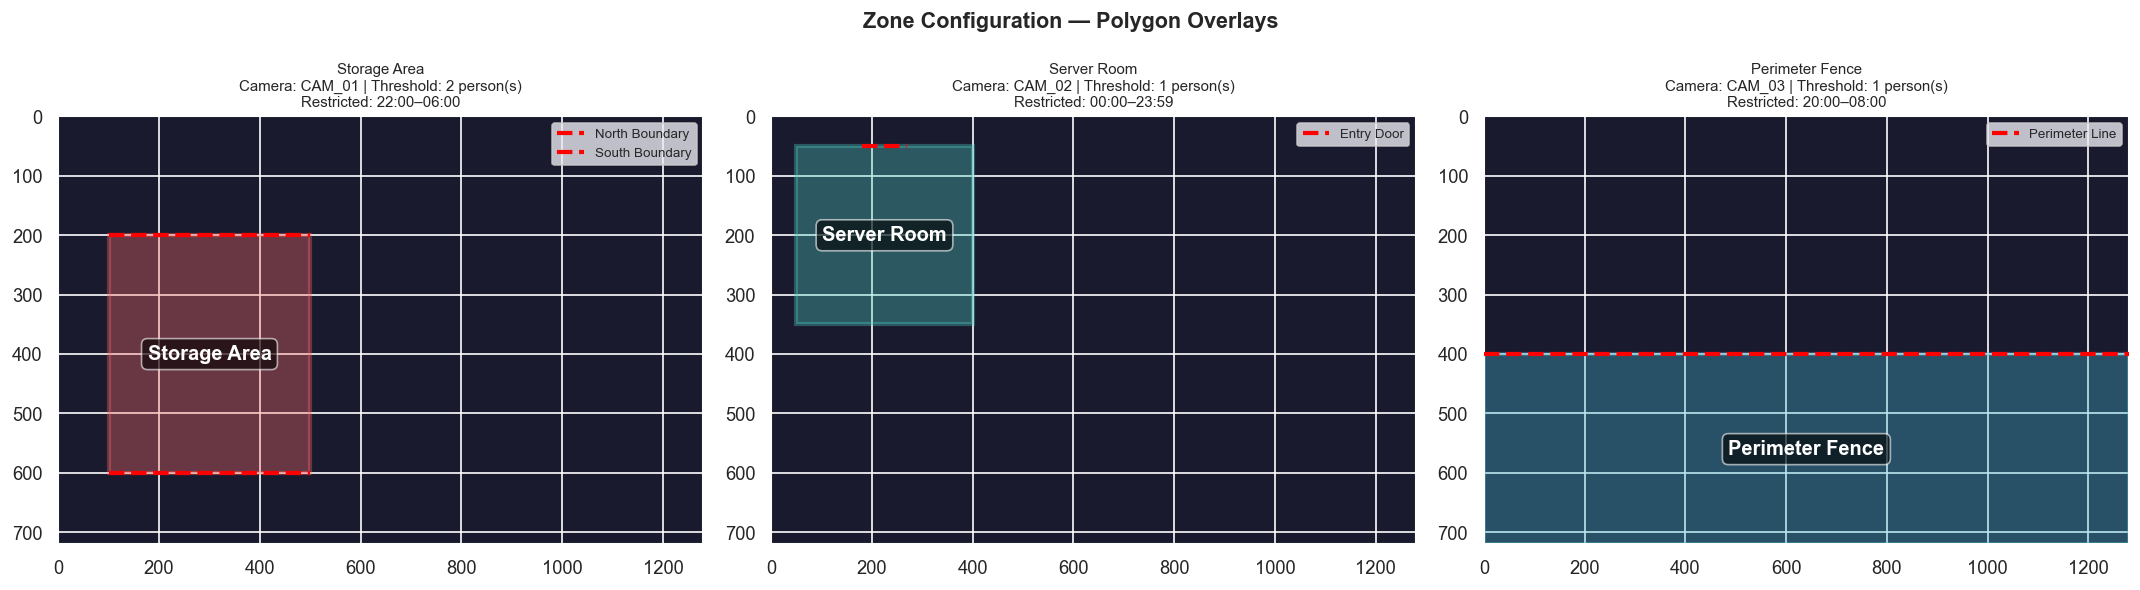

✅ Zone configuration visualized.

📋 Zone Summary:
  Storage Area         | Camera: CAM_01 | Threshold: 2 | Restricted: 22:00 → 06:00
  Server Room          | Camera: CAM_02 | Threshold: 1 | Restricted: 00:00 → 23:59
  Perimeter Fence      | Camera: CAM_03 | Threshold: 1 | Restricted: 20:00 → 08:00


In [21]:
# ── Visualize Zone Configuration ─────────────────────────────
if ZONES_FILE.exists():
    with open(ZONES_FILE) as f:
        zones = json.load(f)
    
    fig, axes = plt.subplots(1, len(zones), figsize=(6 * len(zones), 5))
    if len(zones) == 1:
        axes = [axes]
    fig.suptitle('Zone Configuration — Polygon Overlays', fontsize=13, fontweight='bold')
    
    zone_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    for ax, zone, color in zip(axes, zones, zone_colors):
        # Draw 1280x720 canvas
        canvas = np.zeros((720, 1280, 3), dtype=np.uint8)
        canvas[:] = [30, 30, 40]  # dark background
        
        pts = np.array(zone['polygon'], dtype=np.int32)
        overlay = canvas.copy()
        cv2.fillPoly(overlay, [pts], [int(c*255) for c in 
                     [int(color[1:3], 16)/255 if len(color)==7 else 0.5 
                      for _ in range(3)]])
        
        # Use matplotlib for cleaner rendering
        polygon = plt.Polygon(zone['polygon'], 
                              facecolor=color, alpha=0.35, 
                              edgecolor=color, linewidth=2.5)
        ax.add_patch(polygon)
        
        # Draw boundary lines
        for bl in zone.get('boundary_lines', []):
            sx, sy = bl['start']
            ex, ey = bl['end']
            ax.plot([sx, ex], [sy, ey], 'r--', lw=2.5, 
                    label=bl['name'], zorder=5)
        
        # Zone center label
        cx = np.mean([p[0] for p in zone['polygon']])
        cy = np.mean([p[1] for p in zone['polygon']])
        ax.text(cx, cy, zone['name'], ha='center', va='center',
                fontsize=12, fontweight='bold', color='white',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))
        
        ax.set_xlim(0, 1280)
        ax.set_ylim(720, 0)  # flip y for image coords
        ax.set_facecolor('#1a1a2e')
        hours = zone.get('restricted_hours', {})
        ax.set_title(f"{zone['name']}\n"
                     f"Camera: {zone['camera_id']} | "
                     f"Threshold: {zone['person_threshold']} person(s)\n"
                     f"Restricted: {hours.get('start','N/A')}–{hours.get('end','N/A')}",
                     fontsize=9)
        if zone.get('boundary_lines'):
            ax.legend(fontsize=8, loc='upper right')
    
    plt.tight_layout()
    plt.savefig('eda_zone_config.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('✅ Zone configuration visualized.')
    
    print('\n📋 Zone Summary:')
    for z in zones:
        print(f"  {z['name']:20s} | Camera: {z['camera_id']} | "
              f"Threshold: {z['person_threshold']} | "
              f"Restricted: {z.get('restricted_hours',{}).get('start','–')} "
              f"→ {z.get('restricted_hours',{}).get('end','–')}")

In [22]:
# ── EDA Summary ──────────────────────────────────────────────
print('=' * 60)
print('  ✅ EDA Complete — Summary')
print('=' * 60)
print()
print('  GPU Setup:')
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f'    ✅ {gpu.name} — {gpu.total_memory/1e9:.1f} GB VRAM')
    print(f'    → Recommended: YOLOv8s, batch_size=8, FP16=True')
print()
print('  Datasets:')
print('    COCO 2017  → Person detection base training')
print('    MOT17      → Multi-person tracking sequences')
print('    VIRAT      → Outdoor surveillance (register at viratdata.org)')
print()
print('  Key Observations:')
print('    - Average 2-3 persons per COCO image (suitable for training)')
print('    - Small persons (<32px) present — model must handle scale variation')
print('    - MOT17 provides temporal tracking labels for ByteTrack fine-tuning')
print()
print('  ➡️  Next: Run Notebook 02 — Preprocessing Pipeline')

  ✅ EDA Complete — Summary

  GPU Setup:
    ✅ Quadro T2000 — 4.3 GB VRAM
    → Recommended: YOLOv8s, batch_size=8, FP16=True

  Datasets:
    COCO 2017  → Person detection base training
    MOT17      → Multi-person tracking sequences
    VIRAT      → Outdoor surveillance (register at viratdata.org)

  Key Observations:
    - Average 2-3 persons per COCO image (suitable for training)
    - Small persons (<32px) present — model must handle scale variation
    - MOT17 provides temporal tracking labels for ByteTrack fine-tuning

  ➡️  Next: Run Notebook 02 — Preprocessing Pipeline
